# Connect as a client to an MCP Server

In [1]:
from dotenv import load_dotenv
load_dotenv("../../.env")


from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from IPython.display import Image, display

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage, convert_to_openai_messages

from qdrant_client.http.models import MatchValue, FieldCondition, Filter
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, RrfQuery, Rrf

import openai
from qdrant_client import QdrantClient
from langsmith import traceable, get_current_run_tree
import instructor
from pydantic import BaseModel, Field

from jinja2 import Template

from typing import Annotated, List, Any
from operator import add

# persistence in multi turn conversations
from langgraph.checkpoint.postgres.aio import AsyncPostgresSaver
import os

# MCP
from fastmcp import Client

/Users/dom/Documents/GitHub/e2e-engineering-course/E2E-AI-Engineering-Bootcamp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# list available tools
items_client = Client("http://localhost:8001/mcp")
reviews_client = Client("http://localhost:8002/mcp")

In [3]:
async def list_mcp_tools(mcp_client: Client):
    async with mcp_client:
        client_tools = await mcp_client.list_tools()

    for tool in client_tools:
        print("### Name:\n", tool.name)
        print("### Description:\n", tool.description)
        print("### Input Schema:\n", tool.inputSchema)

In [4]:
await list_mcp_tools(items_client)

### Name:
 retrieve_formatted_context
### Description:
 Retrieves information about available products as a formatted string with each products id, rating and description on a single line starting with a "-".
The search is performed using BM25 and cosine similarity with RRF and reranking afterwards to retrieve the k items.

Arg:
    query: The search string that is used to perform search for products
    k: Top k items that will be returned by the tool

Returns:
    A formatted string that contains the k products that best fit the searched query
### Input Schema:
 {'additionalProperties': False, 'properties': {'query': {'type': 'string'}, 'k': {'default': 10, 'type': 'integer'}}, 'required': ['query'], 'type': 'object'}


In [5]:
await list_mcp_tools(reviews_client)

### Name:
 retrieve_prefiltered_reviews
### Description:
 Retrieves reviews for a list of parent ASINs as a formatted string with each review on a single line starting with a "-".
The search is performed using BM25 and cosine similarity with RRF and reranking afterwards to retrieve the k items.
### Input Schema:
 {'additionalProperties': False, 'properties': {'query': {'type': 'string', 'description': 'The search string that is used to perform search for reviews'}, 'parent_asins': {'items': {'type': 'string'}, 'type': 'array', 'description': 'The list of parent ASINs to filter the reviews by'}, 'k': {'default': 10, 'type': 'integer', 'description': 'The number of reviews to retrieve'}}, 'required': ['query', 'parent_asins'], 'type': 'object'}


### Execute a tool on the client side

In [6]:
async with items_client:
    result = await items_client.call_tool(
        "retrieve_formatted_context", 
        {
            "query": "Give me some earphones", 
            "k": 10
        }
    )

In [7]:
result

CallToolResult(content=[TextContent(type='text', text='- ID: B0BBF2VC6X, rating: 4.2, description: Volkano Ninja Kids Earphones for Boys with Carry Case and Keyring - 3.5MM Stereo Jack - Wired Earbuds with Safe Volume 85dB - Earbuds for Kids for School for Online Learning/Travel/Tablet - Red/Blue HEARING PROTECTION: Made not just to look cool, but to be safe too. These kids\' earbuds with case limit their sound intensity to 85db to protect your kid\'s ears from discomfort during extended periods of listening to music. These wired earbuds provide a noise-isolating effect that removes external ambient sounds. MINI BAG FOR EARPHONES: This pouch may look small, but it\'s enough to store earphones for kids and their accessories, making it perfect for small toys as well! This mini bag can be carried in your child\'s hands with no trouble and has a zippered closure that prevents the bag\'s contents from spilling. The carry case has a soft interior and a sewn-in mesh side pocket for storing th

In [8]:
print(result.content[0].text)

- ID: B0BBF2VC6X, rating: 4.2, description: Volkano Ninja Kids Earphones for Boys with Carry Case and Keyring - 3.5MM Stereo Jack - Wired Earbuds with Safe Volume 85dB - Earbuds for Kids for School for Online Learning/Travel/Tablet - Red/Blue HEARING PROTECTION: Made not just to look cool, but to be safe too. These kids' earbuds with case limit their sound intensity to 85db to protect your kid's ears from discomfort during extended periods of listening to music. These wired earbuds provide a noise-isolating effect that removes external ambient sounds. MINI BAG FOR EARPHONES: This pouch may look small, but it's enough to store earphones for kids and their accessories, making it perfect for small toys as well! This mini bag can be carried in your child's hands with no trouble and has a zippered closure that prevents the bag's contents from spilling. The carry case has a soft interior and a sewn-in mesh side pocket for storing the earphones, in addition to 3 sets of earphone caps (S/M /L)

### Tool Calling via LangChain

In [9]:
from langchain_mcp_adapters.client import MultiServerMCPClient

In [10]:
client = MultiServerMCPClient(
    {
        "items_mcp_server": {
            "url": "http://localhost:8001/mcp",
            "transport": "http"
        },
        "reviews_mcp_server": {
            "url": "http://localhost:8002/mcp",
            "transport": "http"
        },
    }
)

In [11]:
multi_mcp_tools = await client.get_tools()

In [12]:
multi_mcp_tools

[StructuredTool(name='retrieve_formatted_context', description='Retrieves information about available products as a formatted string with each products id, rating and description on a single line starting with a "-".\nThe search is performed using BM25 and cosine similarity with RRF and reranking afterwards to retrieve the k items.\n\nArg:\n    query: The search string that is used to perform search for products\n    k: Top k items that will be returned by the tool\n\nReturns:\n    A formatted string that contains the k products that best fit the searched query', args_schema={'additionalProperties': False, 'properties': {'query': {'type': 'string'}, 'k': {'default': 10, 'type': 'integer'}}, 'required': ['query'], 'type': 'object'}, metadata={'_meta': {'fastmcp': {'tags': []}}}, handle_tool_error=<function _handle_mcp_tool_error at 0x164d0e840>, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x164d64f40>),
 Structured

In [13]:
# calling one of the tools in the combined langchain object
result = await multi_mcp_tools[0].ainvoke(
        {
            "query": "Give me some earphones", 
            "k": 10
        }
)

In [14]:
result

[{'type': 'text',
  'text': '- ID: B0BBF2VC6X, rating: 4.2, description: Volkano Ninja Kids Earphones for Boys with Carry Case and Keyring - 3.5MM Stereo Jack - Wired Earbuds with Safe Volume 85dB - Earbuds for Kids for School for Online Learning/Travel/Tablet - Red/Blue HEARING PROTECTION: Made not just to look cool, but to be safe too. These kids\' earbuds with case limit their sound intensity to 85db to protect your kid\'s ears from discomfort during extended periods of listening to music. These wired earbuds provide a noise-isolating effect that removes external ambient sounds. MINI BAG FOR EARPHONES: This pouch may look small, but it\'s enough to store earphones for kids and their accessories, making it perfect for small toys as well! This mini bag can be carried in your child\'s hands with no trouble and has a zippered closure that prevents the bag\'s contents from spilling. The carry case has a soft interior and a sewn-in mesh side pocket for storing the earphones, in addition t

In [15]:
print(result[0]["text"])

- ID: B0BBF2VC6X, rating: 4.2, description: Volkano Ninja Kids Earphones for Boys with Carry Case and Keyring - 3.5MM Stereo Jack - Wired Earbuds with Safe Volume 85dB - Earbuds for Kids for School for Online Learning/Travel/Tablet - Red/Blue HEARING PROTECTION: Made not just to look cool, but to be safe too. These kids' earbuds with case limit their sound intensity to 85db to protect your kid's ears from discomfort during extended periods of listening to music. These wired earbuds provide a noise-isolating effect that removes external ambient sounds. MINI BAG FOR EARPHONES: This pouch may look small, but it's enough to store earphones for kids and their accessories, making it perfect for small toys as well! This mini bag can be carried in your child's hands with no trouble and has a zippered closure that prevents the bag's contents from spilling. The carry case has a soft interior and a sewn-in mesh side pocket for storing the earphones, in addition to 3 sets of earphone caps (S/M /L)

### Using the MCP tools inside the agent Workflow

In [16]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding

### Structured Outputs of the Agent

In [17]:
class RagUsedContext(BaseModel):
    id: str = Field(description="ID of the item used to answer the question")
    description: str = Field(description="Description of the item used to answer the question")

class FinalResponse(BaseModel):
    answer: str = Field(description="Final answer to the question")
    citations: list[RagUsedContext] = Field(description="List of items that were relevant to create the final answer")

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False
    question_relevant: bool = False

### Agent Node

In [18]:
from langchain_core.messages import AIMessage
@traceable(
    name="rag_agent_node",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def agent_node(state: State) -> dict:
    jinja_prompt_template = """# Role: 
    - You are a shopping assistant that answers customer questions about the available products on our marketplace.

    # Goal: 
    - Give the customer a direct and polite answer to their question given the output of available tools. If the tools did not yield any relevant information mention that you are not able to find information on it, if there is no information in the context.

    # Instructions:
    - Use available tools to answer product related questions
    - Never fabricate information about products that are not mentioned in the context or through tool calls
    - When discribing products use relevant details
    - If there are no products returned by any tools, ask the customer to rephrase their request and you were not able to find anything related to this request
    - If the customer doesn't state anything related to products in their request ask them to specify which product they are interested in
    - Refer to data in context always as "available products" and never as "context"
    - Try answering queries that are not previse by broadening the search radius i.e. product categories instead of specific brand
    """
    template = Template(jinja_prompt_template)

    prompt = template.render()

    llm_client = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort="none",
        use_responses_api=True
    )

    llm_client_with_tools = llm_client.bind_tools(
        [*multi_mcp_tools, FinalResponse], # injecting the multi MCP server tools
        tool_choice="auto"
    )

    response = llm_client_with_tools.invoke([
        SystemMessage(content=prompt),
        *state.messages
    ])

    final_answer = False
    answer = ""
    citations = []


    def sanitise_repsonse(response):
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                answer = tool_call.get("args").get("answer")
                break
                # removing any toolcall suggestions by doing so
        return AIMessage(content=answer)

    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                final_answer = True
                answer = tool_call.get("args").get("answer")
                citations.extend(tool_call.get("args").get("citations"))

                response = sanitise_repsonse(response)
                break

    return {
        "messages": [response],
        "final_answer": final_answer,
        "answer": answer,
        "citations": citations,
        "iteration": state.iteration + 1
    }


In [19]:
def tool_router_conditional_edges(state: State) -> dict:
    if state.final_answer:
        return "end"
    elif state.iteration >= 3:
        return "end"
    elif len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [20]:
workflow = StateGraph(State)

tools = [*multi_mcp_tools]
tool_node = ToolNode(tools)

# nodes
workflow.add_node("agent_node", agent_node)
workflow.add_node("tool_node", tool_node)


# edges
workflow.add_edge(START, "agent_node")
workflow.add_conditional_edges(
    "agent_node",
    tool_router_conditional_edges,
    {
        "tools": "tool_node",
        "end": END
    }
)
workflow.add_edge("tool_node", "agent_node")
workflow.add_edge("agent_node", END)

graph = workflow.compile()


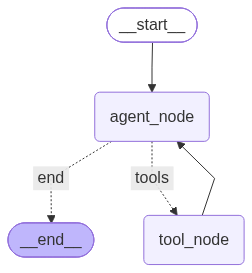

In [21]:
display(Image(
    graph.get_graph().draw_mermaid_png()
))

### Persistent State

In [22]:
# setup postgres DB
db = os.environ["MULTI_TURN_POSTGRES_DB"]
user = os.environ["MULTI_TURN_POSTGRES_USER"]
password = os.environ["MULTI_TURN_POSTGRES_PASSWORD"]
HOST = "localhost"
PORT = "5432"

### Multiturn Conversation

In [26]:
initial_state = {
    "messages": [HumanMessage(content="Can I get a tablet for my kid, a watch for my wife and a waterproof speaker for my pool party?")],
}

config = {
    "configurable": {
        "thread_id": "00000000006"
    }
}

async with AsyncPostgresSaver.from_conn_string(
    f"postgresql://{user}:{password}@{HOST}:{PORT}/{db}"
    ) as checkpointer:
    graph = workflow.compile(checkpointer=checkpointer)

    result = await graph.ainvoke(initial_state, config)

/var/folders/f_/mtgsl6n13zd4n7z20x96lx1m0000gn/T/ipykernel_484/214159645.py:16: RuntimeWarning: coroutine 'Pregel.ainvoke' was never awaited
  result = await graph.ainvoke(initial_state, config)


In [27]:
print(result["messages"][-1].content[0]["text"])

Here are a few available products that could fit what you’re looking for:

- For your kid: I found kids-friendly audio/accessory items, like **Kids Wireless Headphones** (ID: B09KQP2H7N) and **Volkano Ninja Kids Earphones** (ID: B0BBF2VC6X). I wasn’t able to find a tablet itself in the available products.
- For your wife: I found a **Smart Watch for Women Men** (ID: B09P4QW5Y2) that has call features, health tracking, and a fashionable look. I also found another **Smart Watch** option (ID: B09V2Y1TQB).
- For your pool party: I found a **Raymate Bluetooth Speaker** (ID: B0C996WY16) with **IPX7 waterproof** protection and portable party-friendly sound.

If you want, I can narrow these down by age, style, or budget.


In [65]:
initial_state_2 = {
    "messages": [HumanMessage(content="Ah that bluetooth speaker sounds good, which brands are available?")],
    "iteration": 0,
    "final_answer": False
}

with PostgresSaver.from_conn_string(
    f"postgresql://{user}:{password}@{HOST}:{PORT}/{db}"
    ) as checkpointer:
    graph = workflow.compile(checkpointer=checkpointer)

    result = graph.invoke(initial_state_2, config)

In [66]:
result

{'messages': [HumanMessage(content='Can I get a tablet for my kid, a watch for my wife and a waterproof speaker for my pool party?', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'arguments': '{"query":"tablet for kids child tablet family educational tablet", "k":5}', 'call_id': 'call_RyrGgXxd9EJ8OjQVuC8Up9yz', 'name': 'retrieve_formatted_context', 'type': 'function_call', 'id': 'fc_00a326a3c597ef43006a5f12bde9a881a38a36e91b2a2b23d1', 'status': 'completed'}, {'arguments': '{"query":"women\'s watch watch for wife smartwatch elegant watch", "k":5}', 'call_id': 'call_t3UurHW11E3yLx8KbeX4lr1d', 'name': 'retrieve_formatted_context', 'type': 'function_call', 'id': 'fc_00a326a3c597ef43006a5f12bde9b881a3a962000af597d1c7', 'status': 'completed'}, {'arguments': '{"query":"waterproof speaker pool party bluetooth speaker outdoor waterproof", "k":5}', 'call_id': 'call_QGVvwHsqBGlRLoPRRh0UylJG', 'name': 'retrieve_formatted_context', 'type': 'function_call', 'id': 'fc_00a326a3c59

In [67]:
print(result["messages"][-1].content[0]["text"])

The available products I found for the waterproof Bluetooth speaker are from **Raymate**.

- **Raymate Bluetooth Speakers** — 4.7 rating, **30W IPX7 waterproof**, portable, and made for **home, outdoor, and party** use.

If you want, I can also look for more speaker brand options, but this is the main one I found in the available products.
